# 04 — The full GPT

The final ingredients turn one block into a deep stack:

* **Residual connections** — `x = x + sublayer(x)` instead of `x = sublayer(x)`. This keeps an identity highway running the full depth so gradients reach the early layers; it is what makes a 4-block stack trainable.
* **LayerNorm (pre-norm)** — normalize each sub-layer's *input*, leaving the skip path clean.
* **Depth** — four such blocks stacked.

This is the architecture analyzed in `../05_attention_analysis.ipynb`. To keep this notebook fast and the analysis reproducible we **load the committed checkpoint** (`assets/gpt.pth`) rather than retraining; the training curve stored alongside it is plotted below. The checkpoint is trained **to convergence (30k steps)** with seed 1337 (`python train_gpt.py`). Holding training fixed at the progression's 5k-step budget, this same architecture reaches val ~1.80; the extra training closes most of the remaining gap and is used because the analysis benefits from a converged model.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import torch, matplotlib.pyplot as plt
from gpt import make_dataset, train, generate, set_seed, TrainConfig

ds = make_dataset()
print("vocab:", ds.vocab_size, "| train tokens:", len(ds.train_data), "| val tokens:", len(ds.val_data))

vocab: 65 | train tokens: 1003854 | val tokens: 111540


In [2]:
import json, os
from models import GPT

ckpt = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "assets", "gpt.pth"))
model = GPT.from_pretrained(ckpt)
print(model.config)
print(f"{model.num_params()/1e6:.6f}M parameters")

history = json.load(open(os.path.abspath(os.path.join(os.getcwd(), "..", "..", "assets", "gpt_history.json"))))

GPTConfig(vocab_size=65, block_size=32, n_embd=64, n_head=4, n_layer=4, dropout=0.0)
0.209729M parameters


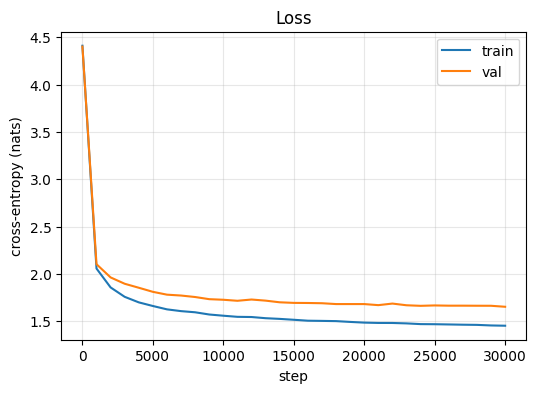

final: {'step': 30000, 'train': 1.4535675048828125, 'val': 1.653650164604187}



First no pardon fare's consul father,
That I differ deposed more all will Marry comes
Wound idle and made I rew me has subjects.

DUKE VINCENTIO:
We kchild, that Oxford begrect with will with any on
For winder far, prie on swever.
Well, envy, he'll I gival: Never for wherempts, bearth out and never
Against the withat thou, breathed darkling
Caenom, him proclarends night, what,
The harts of 'Ttes. 


In [3]:
steps = [h["step"] for h in history]
plt.figure(figsize=(6,4))
plt.plot(steps, [h["train"] for h in history], label="train")
plt.plot(steps, [h["val"] for h in history], label="val")
plt.xlabel("step"); plt.ylabel("cross-entropy (nats)"); plt.legend()
plt.title("Loss"); plt.grid(alpha=0.3); plt.show()
print("final:", history[-1])

# sample
out = generate(model, torch.zeros((1,1), dtype=torch.long), max_new_tokens=400, block_size=32)
print(ds.tokenizer.decode(out[0].tolist()))

**Takeaway.** The full 4-block GPT, trained to convergence, reaches a val loss of **~1.65 nats** (≈1.80 at the fixed 5k budget the earlier stages use). The samples now have speaker labels, line breaks, and mostly-pronounceable words — the model has learned local orthography and the play's formatting, even if it has nothing to say. The next notebook opens this model up and asks *how* it does it: which heads matter, what they attend to, and where information flows.